In [24]:
## PREM R
## 212223240124


In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary

In [51]:
from torchsummary import summary
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [53]:
# Transform: Normalize and convert to tensor
transform = transforms.Compose([
    transforms.ToTensor()])

In [55]:
# Load MNIST dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [56]:
# Add noise to images
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)

In [57]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16,
                kernel_size=3,
                stride=2,
                output_padding=1,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                16, 1,
                kernel_size=3,
                stride=2,
                output_padding=1,
                padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [58]:
# Initialize model, loss function and optimizer
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Print model summary
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 14, 14]             160
              ReLU-2           [-1, 16, 14, 14]               0
            Conv2d-3             [-1, 32, 7, 7]           4,640
              ReLU-4             [-1, 32, 7, 7]               0
   ConvTranspose2d-5           [-1, 16, 14, 14]           4,624
              ReLU-6           [-1, 16, 14, 14]               0
   ConvTranspose2d-7            [-1, 1, 28, 28]             145
           Sigmoid-8            [-1, 1, 28, 28]               0
Total params: 9,569
Trainable params: 9,569
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.13
Params size (MB): 0.04
Estimated Total Size (MB): 0.17
----------------------------------------------------------------


In [33]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 14, 14]             160
              ReLU-2           [-1, 16, 14, 14]               0
            Conv2d-3             [-1, 32, 7, 7]           4,640
              ReLU-4             [-1, 32, 7, 7]               0
   ConvTranspose2d-5           [-1, 16, 14, 14]           4,624
              ReLU-6           [-1, 16, 14, 14]               0
   ConvTranspose2d-7            [-1, 1, 28, 28]             145
           Sigmoid-8            [-1, 1, 28, 28]               0
Total params: 9,569
Trainable params: 9,569
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.13
Params size (MB): 0.04
Estimated Total Size (MB): 0.17
----------------------------------------------------------------


In [62]:
# Train the autoencoder
# Train the autoencoder
def train(model, loader, criterion, optimizer, epochs=5):

    model.train()

    print("Name: PREM R")
    print("Register Number: 212223240124")

    for epoch in range(epochs):

        running_loss = 0.0

        for images, _ in loader:

            # Move images to device
            images = images.to(device)

            # Add noise
            noisy_images = add_noise(images).to(device)

            # Forward pass
            outputs = model(noisy_images)

            # Calculate loss
            loss = criterion(outputs, images)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Add loss
            running_loss += loss.item()

        # Average loss for epoch
        epoch_loss = running_loss / len(loader)

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {epoch_loss:.4f}"
        )

In [63]:
train(model, train_loader, criterion, optimizer, epochs=30)

Name: PREM R
Register Number: 212223240124
Epoch [1/30], Loss: 0.0137
Epoch [2/30], Loss: 0.0135
Epoch [3/30], Loss: 0.0133
Epoch [4/30], Loss: 0.0132
Epoch [5/30], Loss: 0.0131
Epoch [6/30], Loss: 0.0130
Epoch [7/30], Loss: 0.0129
Epoch [8/30], Loss: 0.0128
Epoch [9/30], Loss: 0.0128
Epoch [10/30], Loss: 0.0127
Epoch [11/30], Loss: 0.0127
Epoch [12/30], Loss: 0.0126
Epoch [13/30], Loss: 0.0126
Epoch [14/30], Loss: 0.0125
Epoch [15/30], Loss: 0.0125
Epoch [16/30], Loss: 0.0125
Epoch [17/30], Loss: 0.0125
Epoch [18/30], Loss: 0.0125
Epoch [19/30], Loss: 0.0124
Epoch [20/30], Loss: 0.0124
Epoch [21/30], Loss: 0.0124
Epoch [22/30], Loss: 0.0124
Epoch [23/30], Loss: 0.0123
Epoch [24/30], Loss: 0.0123
Epoch [25/30], Loss: 0.0123
Epoch [26/30], Loss: 0.0123
Epoch [27/30], Loss: 0.0123
Epoch [28/30], Loss: 0.0122
Epoch [29/30], Loss: 0.0122
Epoch [30/30], Loss: 0.0122


In [64]:
for name, param in model.named_parameters():
    print(name, param.abs().mean().item())

encoder.0.weight 0.20216123759746552
encoder.0.bias 0.45280399918556213
encoder.2.weight 0.13397903740406036
encoder.2.bias 0.09970902651548386
decoder.0.weight 0.12606525421142578
decoder.0.bias 0.09561604261398315
decoder.2.weight 0.3032718300819397
decoder.2.bias 0.36402270197868347


In [65]:
images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    noisy = add_noise(images)
    out = model(noisy)

print("Output max after training:", out.max().item())

Output max after training: 0.9975789189338684


Original min: 0.0
Original max: 1.0
Noisy min: 0.0
Noisy max: 1.0
Output min: 2.2211777661595988e-07
Output max: 0.9980423450469971
Name: 
Register Number: 


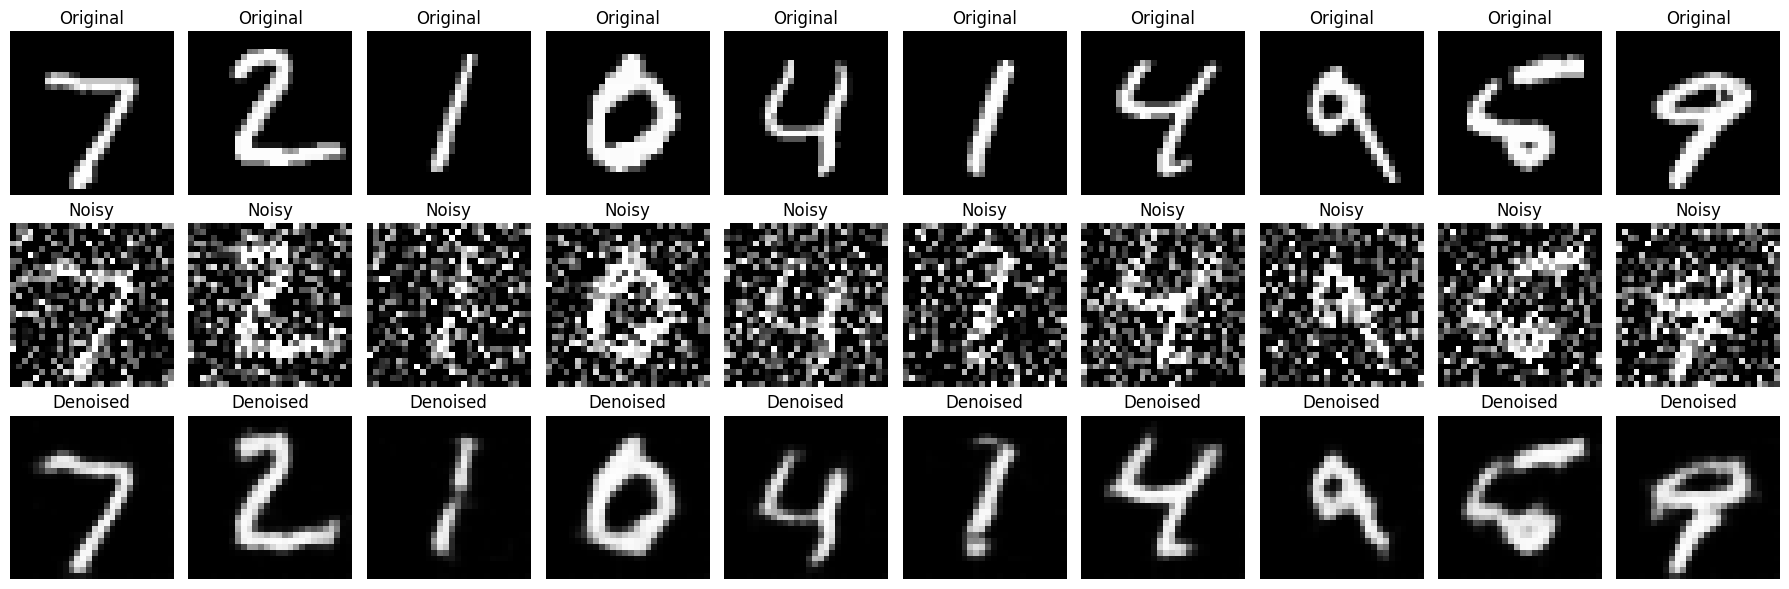

In [66]:
visualize_denoising(model, test_loader)